In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Production

In [2]:
df_prod = pd.read_csv('../production/production_2017_bc1060.csv')

df_prod.columns

Index(['feedstock', 'tillage_type', 'region_production', 'region_destination',
       'equipment_group', 'feedstock_measure', 'feedstock_amount',
       'unit_numerator', 'unit_denominator', 'source_lon', 'source_lat',
       'destination_lon', 'destination_lat'],
      dtype='object')

### Sum production amounts by feedstock and region_production

In [102]:
df_prod_summarized = df_prod \
.loc[(df_prod.tillage_type == 'conventional tillage') & (df_prod.feedstock_measure == 'production')] \
[['feedstock', 'region_production', 'feedstock_amount']] \
.groupby(['feedstock', 'region_production']) \
.sum() \
.reset_index()

### Inspect percentiles of raw production values for region_production == 51019

In [133]:
df_prod_summarized['rank'] = df_prod_summarized[['feedstock', 'feedstock_amount']].groupby(['feedstock']).rank(pct=True)

In [135]:
df_prod_summarized.loc[(df_prod_summarized.feedstock == 'barley') & (df_prod_summarized.region_production == 51019)]

,feedstock,region_production,feedstock_amount,rank
431,barley,51019,483.64072,0.572183


In [160]:
_df = df_prod.loc[(df_prod.feedstock == 'barley') & (df_prod.tillage_type == 'conventional tillage') & (df_prod.feedstock_measure == 'production')][['feedstock', 'region_production', 'region_destination', 'feedstock_amount']]

In [163]:
_df['pct'] = _df.feedstock_amount.rank(pct=True)

In [165]:
_df.loc[(_df.region_production == 51019)]

,feedstock,region_production,region_destination,feedstock_amount,pct
3098,barley,51019,13115,481.80046,0.572935
3158,barley,51019,13319,1.84026,0.031634


In [181]:
_df = df_prod.loc[(df_prod.feedstock == 'corn grain') & (df_prod.tillage_type == 'conventional tillage') & (df_prod.feedstock_measure == 'production')][['feedstock', 'region_production', 'region_destination', 'feedstock_amount']]
_df['pct'] = _df.feedstock_amount.rank(pct=True)
_df.loc[(_df.region_production == 51019)]

,feedstock,region_production,region_destination,feedstock_amount,pct
21203,corn grain,51019,13115,726.96347,0.233916
21272,corn grain,51019,13319,3.37347,0.005752


#### both barley and corn grain have one 51019 production to other destination mapping with really low feedstock amounts, but distributions (below) suggest those values don't get bigger very quickly

In [178]:
_df.loc[_df.feedstock_amount <= 3.37347 * 1000].shape

(2347, 5)

In [183]:
_df.loc[_df.pct >=0.01].head()

,feedstock,region_production,region_destination,feedstock_amount,pct
19103,corn grain,1001,1073,3005.02314,0.387303
19104,corn grain,1003,1099,4768.40066,0.437154
19105,corn grain,1005,1067,1843.74677,0.336174
19106,corn grain,1007,1073,187.95270,0.132936
19107,corn grain,1009,1073,578.99762,0.212186


#### 1st percentile is 1000 times larger so the values do get larger quickly in relative terms

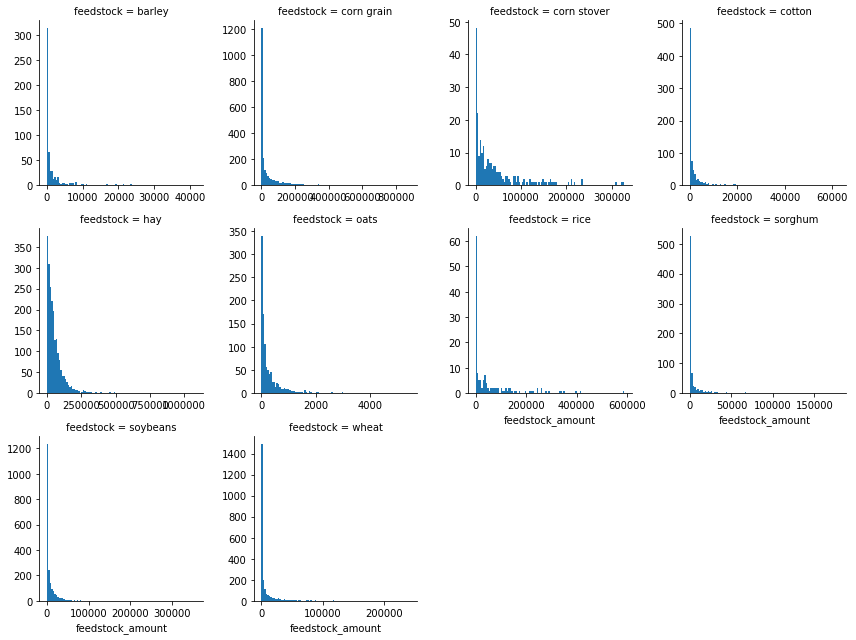

In [180]:
_df = df_prod.loc[(df_prod.tillage_type == 'conventional tillage') & (df_prod.feedstock_measure == 'production')][['feedstock', 'region_production', 'region_destination', 'feedstock_amount']]
g = sns.FacetGrid(_df, col='feedstock', col_wrap=4, sharey=False, sharex=False)
g.map(plt.hist, 'feedstock_amount', bins=100)

In [47]:
_df = df_prod.loc[(df_prod.tillage_type == 'conventional tillage') & (df_prod.feedstock_measure == 'production') & (df_prod.feedstock.isin(['barley', 'corn grain']))]


In [38]:
pd.unique(_df[['unit_numerator', 'unit_denominator']].values.ravel('K'))

array(['dry short ton', nan], dtype=object)

[(0, 10000)]

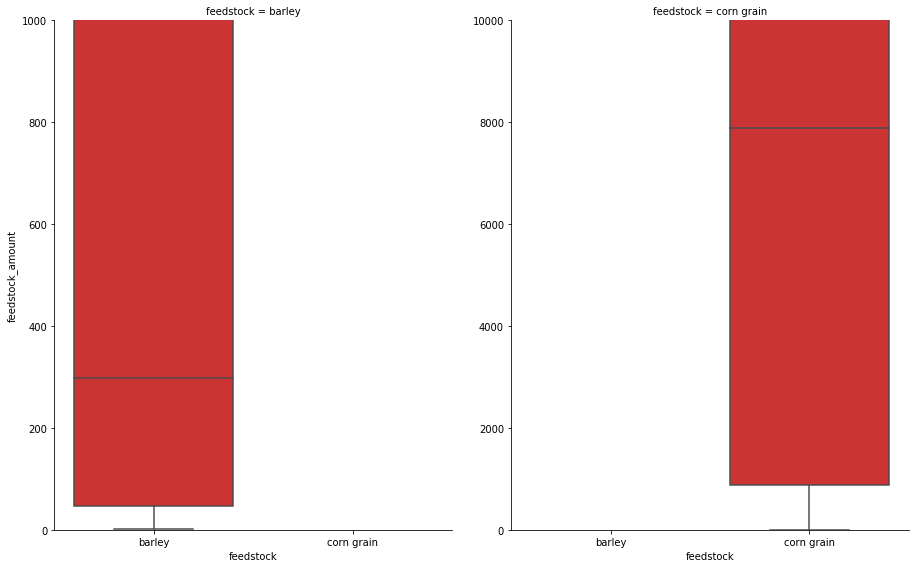

In [46]:

# _df.head()

# sns.boxplot(x="feedstock", y="feedstock_amount", data=_df)

g = sns.catplot(x="feedstock",
                y="feedstock_amount",
#                 hue="pollutant",
                col="feedstock",
                data=_df,
                kind="box",
                height=8,
                aspect=.8,
                color='red',
                sharex=True,
                sharey=False,
#                 margin_titles=False,
                col_wrap=4,
#                 order=_order,
                saturation=0.6,
                dodge=False,
                whis=0.9
               )

g.axes[0].set(ylim=(0, 1000))
g.axes[1].set(ylim=(0, 10000))


In [62]:
_df.loc[_df.region_production == 51019]#[['region_production', 'region_destination', 'equipment_group', 'feedstock', 'feedstock_amount', 'feedstock_measure', 'unit_numerator']]

,feedstock,tillage_type,region_production,region_destination,equipment_group,feedstock_measure,feedstock_amount,unit_numerator,unit_denominator,source_lon,source_lat,destination_lon,destination_lat,feedstock_amount_per,feedstock_amount_rank
3098,barley,conventional tillage,51019.0,13115.0,3.0,production,481.80046,dry short ton,NaN,-79.56554,37.31202,-85.19449,34.33305,0.272634,795.0
3158,barley,conventional tillage,51019.0,13319.0,3.0,production,1.84026,dry short ton,NaN,-79.56554,37.31202,-83.15371,32.79656,0.007202,21.0
21203,corn grain,conventional tillage,51019.0,13115.0,3.0,production,726.96347,dry short ton,NaN,-79.56554,37.31202,-85.19449,34.33305,0.313786,915.0
21272,corn grain,conventional tillage,51019.0,13319.0,3.0,production,3.37347,dry short ton,NaN,-79.56554,37.31202,-83.15371,32.79656,0.015261,44.5


In [63]:
_df.shape

(2917, 15)

In [61]:
_df.loc[:, 'feedstock_amount_rank'] = _df.feedstock_amount.rank()

/Users/dhetting/anaconda2/envs/gds3/lib/python3.7/site-packages/pandas/core/indexing.py:362: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[key] = _infer_fill_value(value)


### Notes

* two region_destinations for same region_production, tillage_type, and feedstock
  * is that normal?
    * [no](http://localhost:8889/notebooks/51019_validation.ipynb#Check-for-other-counties-with-multiple-desitnations), seems to be only 51019
  * do other region_production have multiple region_destinations?
* one set of rows have really small production values- maybe they're being transported a long distance?
  * is it a long distance?
    * not really- 225-250 miles, about the median
  * are they really small feedstock_amount values?
    * small for BTS published numbers?
    * small for raw dataset we have?
      * yes, very small for dataset- around 1st percentile or less
      * e.g., 1st percentile for cg is 1000 times larger
* the other set has relatively normal production values; not sure if they're a part of the problem are just not correctly filtered out
* where are the emissions coming from- which module/activity?

#### Check for other counties with multiple desitnations

    fpeam=# WITH x AS (SELECT region_production, region_destination, COUNT(*) FROM production.production_2017_bc1060  WHERE feedstock_measure = 'production' AND tillage_type = 'conventional tillage' AND feedstock = 'corn grain' GROUP BY region_production, region_destination) SELECT region_production, COUNT(*) FROM x GROUP BY region_production HAVING COUNT(*) > 1;
     ┌───────────────────┬───────┐
     │ region_production │ count │
     ├───────────────────┼───────┤
     │ 51019             │     2 │
     └───────────────────┴───────┘
     (1 row)
    
    
     fpeam=# WITH x AS (SELECT region_production, region_destination, COUNT(*) FROM production.production_2017_bc1060 WHERE feedstock_measure = 'production' AND tillage_type = 'conventional tillage' AND feedstock = 'barley' GROUP BY region_production, region_destination) SELECT region_production, COUNT(*) FROM x GROUP BY region_production HAVING COUNT(*) > 1;
    ┌───────────────────┬───────┐
    │ region_production │ count │
    ├───────────────────┼───────┤
    │ 51019             │     2 │
    └───────────────────┴───────┘
    (1 row)

#### only 51019

In [64]:
df_raw = pd.read_csv('full_run_raw.csv', low_memory=False)

df_raw.columns

Index(['region_production', 'region_destination', 'feedstock', 'tillage_type',
       'module', 'activity', 'resource', 'resource_subtype', 'pollutant',
       'pollutant_amount', 'region_transportation', 'source_lon_x',
       'source_lat_x', 'destination_lon_x', 'destination_lat_x',
       'unit_numerator', 'unit_denominator', 'feedstock_measure',
       'feedstock_amount', 'feedstock_unit_numerator',
       'feedstock_unit_denominator', 'source_lon_y', 'source_lat_y',
       'destination_lon_y', 'destination_lat_y', 'year'],
      dtype='object')

In [71]:
_df = df_raw.loc[(df_raw.tillage_type == 'conventional tillage') & (df_raw.feedstock_measure == 'production') & (df_raw.feedstock.isin(['barley', 'corn grain']))]

In [73]:
_df[['region_production', 'feedstock', 'pollutant', 'pollutant_amount', 'unit_numerator', 'unit_denominator', 'feedstock_measure', 'feedstock_amount', 'feedstock_unit_numerator', 'feedstock_unit_denominator']]

,region_production,feedstock,pollutant,pollutant_amount,unit_numerator,unit_denominator,feedstock_measure,feedstock_amount,feedstock_unit_numerator,feedstock_unit_denominator
21644,24037,barley,voc,7.461058e+00,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21646,24037,barley,co,1.762256e-06,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21648,24037,barley,co,5.712912e-06,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21650,24037,barley,co,2.398809e-06,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21652,24037,barley,nox,4.414838e-06,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21654,24037,barley,nox,1.421589e-05,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21656,24037,barley,nox,4.010940e-06,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21658,24037,barley,so2,5.104098e-09,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21660,24037,barley,so2,1.232407e-08,lb pollutant,county-year,production,244.81003,dry short ton,NaN
21662,24037,barley,so2,4.641276e-09,lb pollutant,county-year,production,244.81003,dry short ton,NaN


In [70]:
df_raw['activity'].loc[df_raw.feedstock_unit_numerator == 'dry short ton'].unique()

array(['chemical application', 'establishment', 'harvest', 'maintenance',
       'irrigation', nan, 'loading'], dtype=object)

In [4]:
df_normalized = pd.read_csv('full_run_normalized_total_emissions_by_production_region.csv')

df_normalized.columns

Index(['feedstock', 'feedstock_measure', 'tillage_type', 'region_production',
       'feedstock_amount', 'feedstock_unit_numerator', 'pollutant',
       'unit_numerator', 'normalized_pollutant_unit_numerator',
       'normalized_pollutant_unit_denominator', 'pollutant_amount',
       'source_lon_x', 'source_lat_x', 'destination_lon_x',
       'destination_lat_x', 'source_lon_y', 'source_lat_y',
       'destination_lon_y', 'destination_lat_y', 'year',
       'normalized_pollutant_amount'],
      dtype='object')

In [40]:
_df = df_normalized.loc[(df_normalized.tillage_type == 'conventional tillage') & (df_normalized.feedstock_measure == 'production') & (df_normalized.feedstock.isin(['barley', 'corn grain']))]

In [41]:
_df.feedstock_unit_numerator.unique()

array(['dry short ton'], dtype=object)

In [5]:
df_by_production_region = pd.read_csv('full_run_total_emissions_by_production_region.csv')

df_by_production_region.columns

Index(['feedstock', 'tillage_type', 'region_production', 'pollutant',
       'pollutant_amount', 'unit_numerator', 'unit_denominator'],
      dtype='object')

In [6]:
df_by_module = pd.read_csv('full_run_total_emissions_by_module.csv')

df_by_module.columns

Index(['feedstock', 'tillage_type', 'module', 'pollutant', 'pollutant_amount'], dtype='object')

#### Check for module source of high emissions

In [192]:
df_by_module.loc[(df_by_module.feedstock == 'barley') & (df_by_module.tillage_type == 'conventional tillage')]

,feedstock,tillage_type,module,pollutant,pollutant_amount
0,barley,conventional tillage,emission factors,voc,739689.762485
1,barley,conventional tillage,nonroad,co,0.132010
2,barley,conventional tillage,nonroad,nh3,0.000481
3,barley,conventional tillage,nonroad,nox,0.328975
4,barley,conventional tillage,nonroad,pm10,0.024075
5,barley,conventional tillage,nonroad,pm25,0.023353
6,barley,conventional tillage,nonroad,so2,0.000340
7,barley,conventional tillage,nonroad,voc,0.027893


In [193]:
df_by_module.module.unique()

array(['emission factors', 'nonroad', 'fugitive dust'], dtype=object)

### <font color=red>[Why isn't 'MOVES' in emissions by module?](https://github.com/NREL/fpeam/issues/139)</font>

In [7]:
df_by_transportation = pd.read_csv('full_run_transportation_emissions_by_region.csv')

df_by_transportation.columns

Index(['feedstock', 'tillage_type', 'region_transportation', 'pollutant',
       'pollutant_amount'],
      dtype='object')

In [194]:
pd.read_csv('full_run_total_emissions_by_module.csv').module.unique()

array(['emission factors', 'nonroad', 'fugitive dust'], dtype=object)

In [195]:
df_raw.module.unique()

array(['emission factors', 'nonroad', 'fugitive dust'], dtype=object)